# Introduction

 

Welcome to the session on Custom Model Building in Tensorflow. 

 

Until now, you have worked with the simple and traditional kind of approach to build a model using the Keras wrapper in Tensorflow. Most of the time the built-in layers and pre-trained models do the job but what if you want to create your own custom models or layers? 

The Tensorflow framework allows us to create models ranging from simple to complex architecture. In the world of deep learning, developers may come from a varied set of background or experience levels. TensorFlow understands this and provides you with different approaches whether you’re a beginner or an experienced person.

In the next section, let's understand how we can do that and look at the different type of approaches which you can utilise for model building.

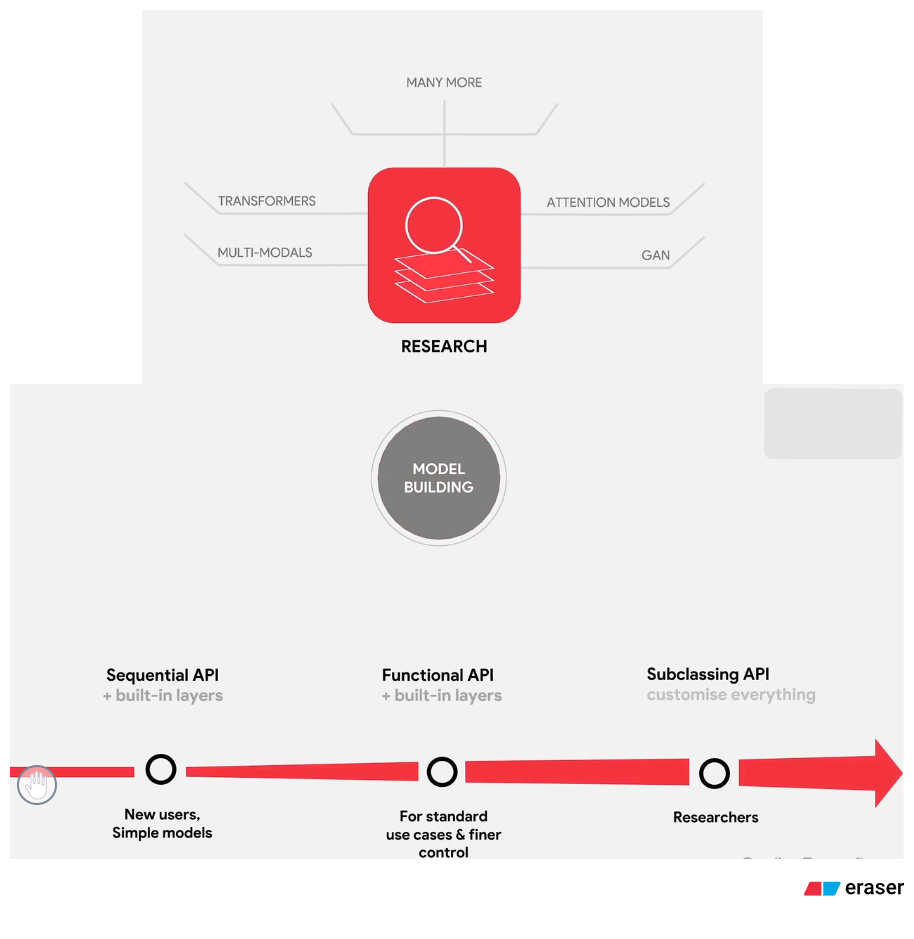

<div class="text_component" data-testid="text-component"><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">The <strong>tf.keras</strong> is TensorFlow’s implementation of the Keras API specification. Now Keras has become a&nbsp;high-level API to build and train models&nbsp;in TensorFlow 2.0 and higher versions. As explained in the video, there are three methods to implement your own neural network architectures in TensorFlow:</p><ul><li style="text-align: justify;">Sequential API</li><li style="text-align: justify;">Functional API</li><li style="text-align: justify;">Model Subclassing</li></ul><p style="text-align: justify;">&nbsp;</p><h2 style="text-align: justify;">In this session</h2><p style="text-align: justify;">In this session, you&nbsp;will understand how to work with custom models and layers using the TensorFlow framework.&nbsp;This session will introduce you to the following topics:&nbsp;</p><ul dir="ltr"><li style="text-align: justify;">Introduction&nbsp;</li><li style="text-align: justify;">Sequential vs Functional API</li><li style="text-align: justify;">Model Subclassing</li><li style="text-align: justify;">Building Custom Models</li><li style="text-align: justify;">Building Custom Layers</li><li style="text-align: justify;">Building Datasets</li><li style="text-align: justify;">Building Custom Training Loops</li></ul>

## Sequential vs Functional API

As seen earlier, there are three kinds of the model building process. Among them, the most used and common is the Sequential and Functional API. They both are user friendly and allows us to work on simple and traditional use-cases.

let's quickly revise the Sequential API approach which you have used in the earlier modules.


### Sequential API: 

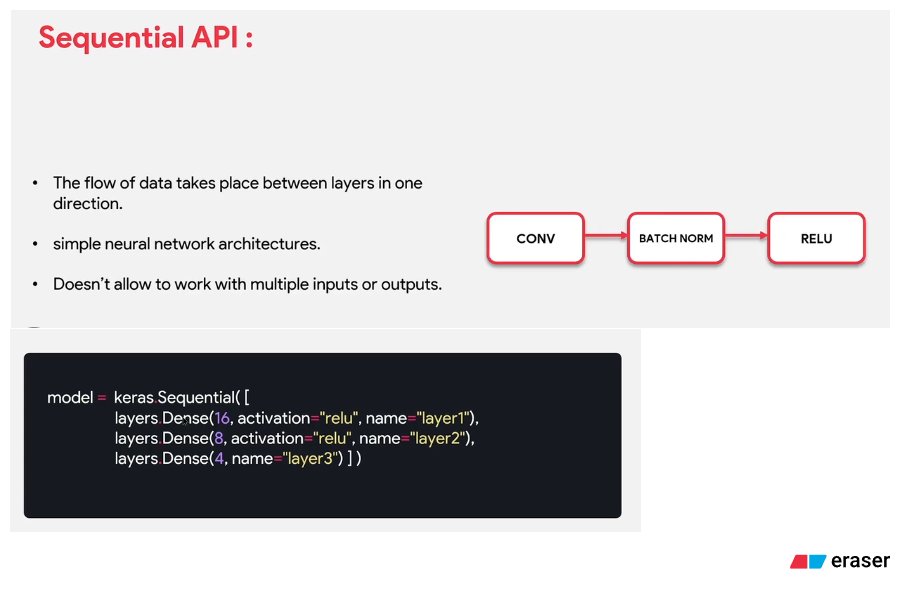

<div class="MuiBox-root css-1bi8ut6"><div class="text_component" data-testid="text-component"><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;"><strong>Sequential API: </strong>Here layers are put in sequential order&nbsp;and the flow of data takes place between layers in one direction.&nbsp;It is the most common type of model&nbsp;to create simple neural network architectures where we have a linear stack of layers.</p><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">This is the best approach for a beginner as it is user-friendly and you&nbsp;can create models by simply plugging together building blocks.&nbsp;The only disadvantage of using the Sequential API is that it doesn’t allow us to build Keras models with multiple inputs or outputs. Instead, it is limited to just 1 input tensor and 1 output tensor.&nbsp;</p><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">Using a sequential() function, you can build your&nbsp;model&nbsp;by passing a list of layers.&nbsp;</p><p style="text-align: justify;">&nbsp;</p><pre style="text-align: justify;">model =  keras.Sequential( [
                  layers.Dense(16, activation="relu", name="layer1"),
	          layers.Dense(8, activation="relu", name="layer2"), 
                  layers.Dense(4, name="layer3") ] )
</pre><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">Sequential models can also be created incrementally using the&nbsp;<code>add()</code>&nbsp;method.</p><pre style="text-align: justify;"><code>model = keras.Sequential()
model.add(layers.Dense(16, activation="relu", </code>name="layer1"<code>))
model.add(layers.Dense(8, activation="relu", </code>name="layer2"<code>))
model.add(layers.Dense(4), </code>name="layer3"<code>)</code></pre><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">You may have already worked with some of the models that utilise Sequential approaches like VGGNet, LeNet and&nbsp;AlexNet.</p></div></div>


So, now that you have understood how we implement the Sequential function for our simple models, let's understand the next model building processes, i.e. through the use of functional APIs.

### Functional API

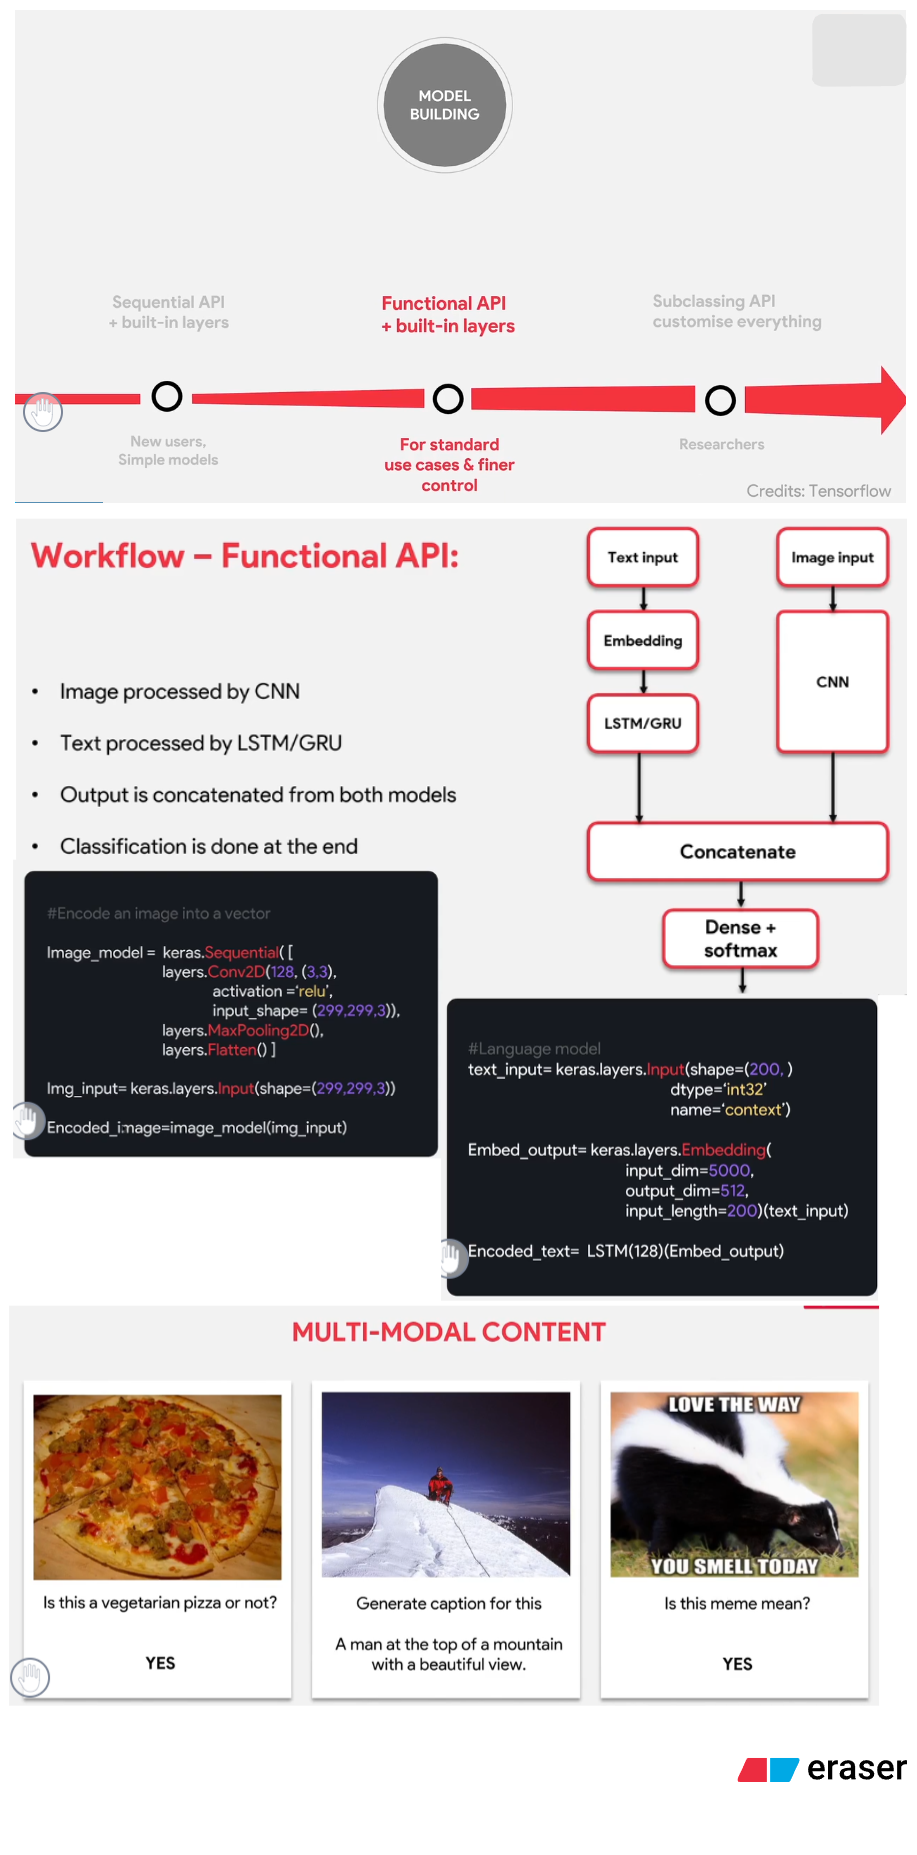

<div class="text_component" data-testid="text-component"><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;"><strong>Functional API:</strong>&nbsp;This type of approach allows you to build neural network models with <strong>multiple inputs/outputs that also possess shared layers</strong>. It can do all the work which you could do with the sequential API and on top of it provides more control over how the layers should interact with each other.</p><p style="text-align: justify;">Here layers are appended to each other by passing input to them. As seen in the video,&nbsp;<strong>x </strong>acted as the&nbsp;input variable to subsequent layers.&nbsp;So compared to the previous approach, here you have a decent degree of customisation which you can add to your model.</p><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">Functional API uses the concept of legos which once you have built, can be fit anywhere to shape your final model. A model might have many blocks&nbsp;in it to perform different operations on the built-in layers.&nbsp;&nbsp;Imagine these&nbsp;blocks as <strong>legos </strong>that can be shaped/stacked in any manner to define the architecture of your model.</p><p style="text-align: center;">&nbsp;</p><p><img alt="Each module inside the models is a lego block. You can&nbsp;stack/shape them in any particular way to build the final model." class="image-center" style="cursor: pointer; border: 2px solid transparent; display: block; margin-left: auto; margin-right: auto; text-align: center;" src="https://images.upgrad.com/c550c5a3-097f-4320-bf01-7331faeaf3d2-legos.jpg.png"></p><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">Once these blocks are built, they can be used any number of times, thus providing us with the benefit of reusability. Let's take an interesting example to understand how we can build blocks and reuse them for defining our model architecture.</p><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">Imagine you want to create a<strong> CNN block</strong> that applies both the convolutional operation and&nbsp;BatchNormalisation. You also want to apply a&nbsp;ReLU activation function to the output of both the above operations.&nbsp;</p><p style="text-align: center;">&nbsp;</p><p><img data-width="214" data-height="219" height="219" width="214" class="image-center" style="cursor: pointer; border: 2px solid transparent; display: block; margin-left: auto; margin-right: auto; text-align: center;" src="https://images.upgrad.com/9d6934f0-a05f-40e8-bcb1-64bc3f51aba8-CNN block.png"></p><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">Here is the code for implementing the block above.</p><pre style="text-align: justify;">def CNN_block(x,filters, kernel_size=3, padding="same"):
    # Defining a function which returns an operation of Convolution, BatchNormalisation and Relu.
    # Here x is the input.
    x = Conv2D(filters, kernel_size=3, padding)(x)
    x = BatchNormalization()(x)
	
    return tf.nn.relu(x)
</pre><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">Now, let's say you want to create an <strong>inception block </strong>that utilises the earlier created CNN block multiple times and produces the output by merging the results from the CNN blocks.</p><p style="text-align: center;">&nbsp;</p><p><img data-width="257" data-height="217" height="217" width="257" class="image-center" style="cursor: pointer; border: 2px solid transparent; display: block; margin-left: auto; margin-right: auto; text-align: center;" src="https://images.upgrad.com/19f9d23c-b214-4b3d-be90-57e4604244ce-Inception block.png"></p><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">Here is the code for implementing the block above.</p><pre style="text-align: justify;">def inception_block(x, filter1, filter2):
	# Defining a function which applies two CNN blocks. The output of both these blocks are then concatenated
	conv1 = CNN_block(x, filter1)
	conv2 = CNN_block(x, filter2)
	x = keras.layers.concatenate([conv1, conv2])

	return x
</pre><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">Here, the <strong>inception_block&nbsp;</strong>uses&nbsp;two branches&nbsp;of the&nbsp;<strong>CNN_block. </strong>The outputs coming from these two branches are then merged together by passing two instances of CNN_block as a list to the&nbsp;<a target="_blank" href="https://keras.io/api/layers/merging_layers/concatenate/"><strong>layers.concatenate</strong></a> layer.</p><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">This feature is called&nbsp;<strong>Shared layers</strong>, where&nbsp;you have <strong>reused the same block again inside our new block/lego.&nbsp;</strong>By&nbsp;sharing the information across two or more different inputs, shared layers&nbsp;allow you to train a model even on lesser data.</p><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">Now that you have defined all the blocks that would be used for the model, you can go ahead and build the architecture for the same. Consider the model that you want to build is the following.</p><pre style="text-align: justify;"><code>(input shape: 28,28,1))
↓
[CNN_block(32 units)]
↓
[MaxPooling2D(3)]
↓
[Inception_block (32 units, 32 units)]
↓
[Inception_block (64 units, 64 units)]
↓
[CNN_block(128 units)]
↓
[</code>GlobalAveragePooling2D<code>()]
↓
[Dense (256 units, relu activation)]
↓
[Dropout(0.5)]
↓
[Dense (10 units)]
↓
(output: logits of a probability distribution over 10 classes</code>
</pre><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">Here is the code for implementing the architecture above.</p><pre style="text-align: justify;">inputs = keras.Input(shape=(28, 28, 1))
x = CNN_block(inputs,32)
x = layers.MaxPooling2D(3)(x)
x = inception_block(x,32, 32)
x = inception_block(x,64, 64)
x = CNN_block(x,128)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(10)(x)
model = keras.Model(inputs, outputs, name="final_model")
model.summary()
</pre>

<p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">The summary of the model is as follows.</p>

<pre style="text-align: justify;">Model: "final_model"
__________________________________________________________________________________________________
    Layer (type)                    Output Shape         Param #     Connected to                     
    ==================================================================================================
    input_1 (InputLayer)            [(None, 28, 28, 1)]  0                                            
    __________________________________________________________________________________________________
    conv2d (Conv2D)                 (None, 28, 28, 32)   320         input_1[0][0]                    
    __________________________________________________________________________________________________
    batch_normalization (BatchNorma (None, 28, 28, 32)   128         conv2d[0][0]                     
    __________________________________________________________________________________________________
    tf.nn.relu (TFOpLambda)         (None, 28, 28, 32)   0           batch_normalization[0][0]        
    __________________________________________________________________________________________________
    max_pooling2d (MaxPooling2D)    (None, 9, 9, 32)     0           tf.nn.relu[0][0]                 
    __________________________________________________________________________________________________
    conv2d_1 (Conv2D)               (None, 9, 9, 32)     9248        max_pooling2d[0][0]              
    __________________________________________________________________________________________________
    conv2d_2 (Conv2D)               (None, 9, 9, 32)     9248        max_pooling2d[0][0]              
    __________________________________________________________________________________________________
    batch_normalization_1 (BatchNor (None, 9, 9, 32)     128         conv2d_1[0][0]                   
    __________________________________________________________________________________________________
    batch_normalization_2 (BatchNor (None, 9, 9, 32)     128         conv2d_2[0][0]                   
    __________________________________________________________________________________________________
    tf.nn.relu_1 (TFOpLambda)       (None, 9, 9, 32)     0           batch_normalization_1[0][0]      
    __________________________________________________________________________________________________
    tf.nn.relu_2 (TFOpLambda)       (None, 9, 9, 32)     0           batch_normalization_2[0][0]      
    __________________________________________________________________________________________________
    concatenate (Concatenate)       (None, 9, 9, 64)     0           tf.nn.relu_1[0][0]               
                                                                     tf.nn.relu_2[0][0]               
    __________________________________________________________________________________________________
    conv2d_3 (Conv2D)               (None, 9, 9, 64)     36928       concatenate[0][0]                
    __________________________________________________________________________________________________
    conv2d_4 (Conv2D)               (None, 9, 9, 64)     36928       concatenate[0][0]                
    __________________________________________________________________________________________________
    batch_normalization_3 (BatchNor (None, 9, 9, 64)     256         conv2d_3[0][0]                   
    __________________________________________________________________________________________________
    batch_normalization_4 (BatchNor (None, 9, 9, 64)     256         conv2d_4[0][0]                   
    __________________________________________________________________________________________________
    tf.nn.relu_3 (TFOpLambda)       (None, 9, 9, 64)     0           batch_normalization_3[0][0]      
    __________________________________________________________________________________________________
    tf.nn.relu_4 (TFOpLambda)       (None, 9, 9, 64)     0           batch_normalization_4[0][0]      
    __________________________________________________________________________________________________
    concatenate_1 (Concatenate)     (None, 9, 9, 128)    0           tf.nn.relu_3[0][0]               
                                                                     tf.nn.relu_4[0][0]               
    __________________________________________________________________________________________________
    conv2d_5 (Conv2D)               (None, 9, 9, 128)    147584      concatenate_1[0][0]              
    __________________________________________________________________________________________________
    batch_normalization_5 (BatchNor (None, 9, 9, 128)    512         conv2d_5[0][0]                   
    __________________________________________________________________________________________________
    tf.nn.relu_5 (TFOpLambda)       (None, 9, 9, 128)    0           batch_normalization_5[0][0]      
    __________________________________________________________________________________________________
    global_average_pooling2d (Globa (None, 128)          0           tf.nn.relu_5[0][0]               
    __________________________________________________________________________________________________
    dense (Dense)                   (None, 256)          33024       global_average_pooling2d[0][0]   
    __________________________________________________________________________________________________
    dropout (Dropout)               (None, 256)          0           dense[0][0]                      
    __________________________________________________________________________________________________
    dense_1 (Dense)                 (None, 10)           2570        dropout[0][0]                    
    ==================================================================================================
    Total params: 277,258
    Trainable params: 276,554
    Non-trainable params: 704
</pre>

<p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">You can also plot the model as a graph using the following command.</p><pre style="text-align: justify;">keras.utils.plot_model(model, "final_model.png", show_shapes=True)
</pre><p style="text-align: justify;">&nbsp;</p><p style="text-align: center;">&nbsp;</p><p><img alt="final_model" class="image-center" style="cursor: pointer; border: 2px solid transparent; display: block; margin-left: auto; margin-right: auto; text-align: center;" src="https://images.upgrad.com/2d99ccb4-f097-4f06-9cdd-d856c19321eb-model.png"></p><p style="text-align: justify;">To learn more about Functional API, read&nbsp;the&nbsp;<a target="_blank" href="https://keras.io/guides/functional_api/">guide.</a></p>


## Model Subclassing:

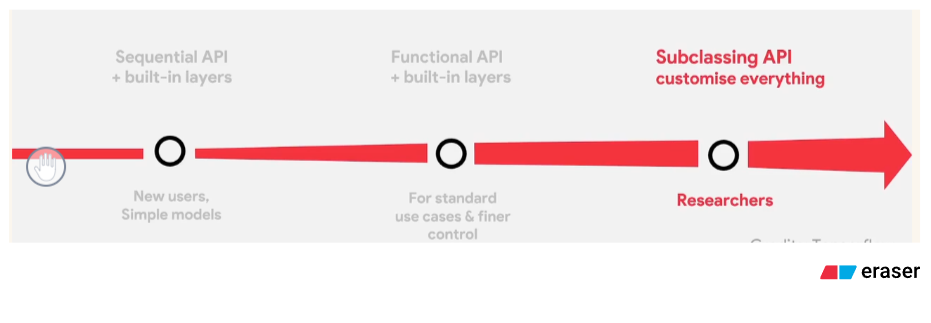

<div class="text_component" data-testid="text-component"><p style="text-align: justify;"><strong>Model Subclassing</strong></p><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">In the previous segment, you have learnt how to implement Sequential and&nbsp; Functional API.</p><p style="text-align: justify;">Among these two, you might have observed that the&nbsp;Sequential API is the easiest approach to build models, but it’s also a naive approach there are many limitations when it comes to:</p><ul><li style="text-align: justify;">Building models with multiple inputs and&nbsp;outputs</li><li style="text-align: justify;">Sharing layers</li></ul><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">The Functional API bridge this gap by allowing you to create more complex models. This approach provides the support of <strong>multiple inputs and multiple outputs, layer&nbsp;sharing, branching and reusability. </strong>But in this approach for each block, we are applying operations on the built-in layers. The Keras API provides you&nbsp;with many built-in layers like:</p><ul><li style="text-align: justify;">Convolutional layers: Conv1D, Conv2D, etc.</li><li style="text-align: justify;">Pooling layers: MaxPooling1D, MaxPooling2D, etc.</li><li style="text-align: justify;">RNN layers: GRU, LSTM, etc.</li><li style="text-align: justify;">BatchNormalization, Dropout, Embedding, etc.</li></ul><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">But if you don't want to work with these built-in layers and you want to create your own layers, then the third approach - <strong>Model Subclassing</strong> provides an elegant solution.</p><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">Model Subclassing<strong>&nbsp;</strong>is tailor-made for advanced developers who want&nbsp;to customise how their <strong>model,&nbsp;layer, and training process</strong> works. Let's understand this in detail in the next video.</p></div>

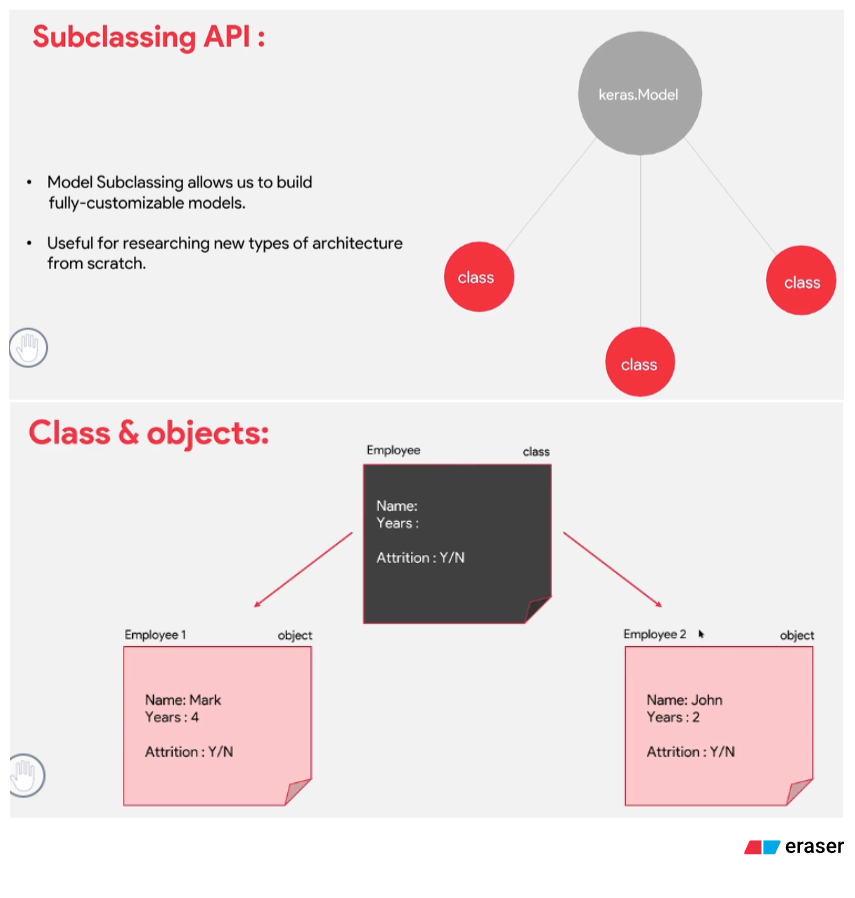

<div class="MuiBox-root css-1bi8ut6"><div class="text_component" data-testid="text-component"><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">As explained in the video, the subclassing approaches are based on the process of creating classes that&nbsp;extend from the&nbsp;<strong><a target="_blank" href="https://www.tensorflow.org/api_docs/python/tf/keras/Model">tf.keras.Model</a> class.&nbsp;</strong>Using the principle of inheritance, these classes inherit the general properties of a model class that is defined already, thus providing us code reusability. Thus the&nbsp;<strong>tf.keras.Model </strong>class&nbsp;becomes the <strong>parent </strong>for these <strong>subclasses</strong>. This is why this approach of custom model building is called&nbsp;<strong>Model Subclassing.</strong></p><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">Here the class that we are defining is a&nbsp;blueprint for creating objects, through which we can define certain characteristics for different objects when created. These characteristics would help in initialisation when each object of a class is initialised.</p></div></div>

<div class="text_component" data-testid="text-component"><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">there are two crucial terms in Model subclassing:</p><ul><li style="text-align: justify;"><strong>__init__ method:</strong>&nbsp;where you can do all input-independent initialisation. The&nbsp;<strong>init</strong>&nbsp;method is similar to constructors in C++ and Java. Constructors are used to initialising the object’s state. The task of constructors is to initialise(assign values) to the data members of the class when an object of the class is created. The method is useful to do any initialisation you want to do with your object.</li><li style="text-align: justify;"><strong>self:</strong>&nbsp;the keyword self represents the instance of a class and binds the attributes with the given arguments. It is an instance of the class that we are building, therefore 'self'&nbsp;represents the objects when they are created.&nbsp;&nbsp;By using the 'self'&nbsp;keyword we can access the attributes and methods of the class and can bind the instance or objects with the attributes at the time of object creation.</li></ul></div>

<p style="text-align: justify;">There is another crucial parameter called&nbsp;<strong>super()&nbsp;</strong>which is very essential for the concept of class and inheritance. Let's understand it in the next video.</p>

## Building Custom Models

<div class="MuiBox-root css-1bi8ut6"><div class="text_component" data-testid="text-component"><p style="text-align: justify;"></p><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">Inheritance is a concept in object-oriented programming in which a class derives (or inherits) attributes and behaviours from another class without needing to implement them again.</p><p style="text-align: justify;">It allows you to call methods of the superclass in your subclass. So, now you will inherit the basic characteristics of <strong>tf.keras.Model class&nbsp;</strong>to build your own custom deep learning models.&nbsp;</p><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">Sandeep will now help you in implementing this using a simple example of the MNIST dataset in the next .</p></div></div>

[WORKSHEET](./8.1 Tensorflow-classing-.ipynb)

<div class="text_component" data-testid="text-component"><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">Here, you have another method,&nbsp;<strong>call()</strong>,<strong>&nbsp;</strong>that you need to utilise in the subclassing approach. Using this method, you can apply different operations which you want to perform for&nbsp;the layers that are defined in the __init__ function earlier. So, the call() method&nbsp;is the place where we define our forward pass of the model.</p><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">By customising the call() method, we are overriding the inherited call method. Therefore we don't need to invoke it using the <strong>model.call()</strong>, it automatically is activated&nbsp;when the instance of your model is called.</p></div>

But as you have seen there is an error that has popped up when we wanted to summarise our model. Let's see how we can resolve this error in the next SECTION.

<div class="MuiBox-root css-1bi8ut6"><div class="text_component" data-testid="text-component"><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">Both the Sequential and Functional API represents a graph structure of layers which is&nbsp;built by stacking layers one on top of each other. Both these approaches can infer the shape of all other layers defined in the model once you have provided the <strong>input_shape</strong> to the first layer. Therefore, you can easily&nbsp;print the input/output shapes using model.summary().</p><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">But on the other hand, model subclassing is defined using the class which is only invoked by the call method. Here,&nbsp;there is no graph structure for&nbsp;layers, so you cannot know how different layers are interacting with each other since that is&nbsp;defined in the body of the class.</p><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">Therefore you cannot infer the input/output shape in the subclassing approach until you have tested with the given data. This is the reason why no error will be thrown if you run the model with the data and then use <strong>model.summary()</strong>.&nbsp;</p><p style="text-align: justify;">&nbsp;</p>

Instead of using our built-in&nbsp;layers or functions, what if you want to create your own dense layer or your own activation function like softmax or ReLU?</p><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">Most of the time when writing code for machine learning models, you want to use the built-in layers as they solve all the traditional problems. But if you want&nbsp;to operate at individual operations and manipulate&nbsp;individual variables, rather than&nbsp;a higher level of abstraction, you need to build classes that extend the&nbsp;<strong><a target="_blank" href="https://www.tensorflow.org/api_docs/python/tf/keras/layers/Layer">tf.keras.Layer class</a>.&nbsp;</strong>Therefore you don't necessarily have to depend upon the built-in layers provided by the Keras API.&nbsp;</p><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">Let's see how we can utilise the concept of subclassing for building new/custom layers.</p></div>

<div class="text_component" data-testid="text-component"><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">Here is a basic implementation of&nbsp;<code>tf.keras.layers.Dense</code>&nbsp;using custom layer.</p><div id="code-snippet-cke_1260" data-lang="python" class="code-snippet-container"><div contenteditable="false" class="code"><pre style="margin: 0; line-height: 125%;"><span></span><span style="color: #008800; font-weight: bold">class</span> <span style="color: #BB0066; font-weight: bold">custom_dense</span>(keras<span style="color: #333333">.</span>layers<span style="color: #333333">.</span>Layer):
    <span style="color: #008800; font-weight: bold">def</span> <span style="color: #0066BB; font-weight: bold">__init__</span>(<span style="color: #007020">self</span>, units, input_dim):
        <span style="color: #007020">super</span>()<span style="color: #333333">.</span><span style="color: #0066BB; font-weight: bold">__init__</span>()
        <span style="color: #007020">self</span><span style="color: #333333">.</span>w <span style="color: #333333">=</span> <span style="color: #007020">self</span><span style="color: #333333">.</span>add_weight(
            name<span style="color: #333333">=</span><span style="background-color: #fff0f0">"w"</span>,
            shape<span style="color: #333333">=</span>(input_dim, units),
            initializer<span style="color: #333333">=</span><span style="background-color: #fff0f0">"random_normal"</span>,
            trainable<span style="color: #333333">=</span><span style="color: #008800; font-weight: bold">True</span>,
        )
        <span style="color: #007020">self</span><span style="color: #333333">.</span>b <span style="color: #333333">=</span> <span style="color: #007020">self</span><span style="color: #333333">.</span>add_weight(
            name<span style="color: #333333">=</span><span style="background-color: #fff0f0">"b"</span>, shape<span style="color: #333333">=</span>(units,), initializer<span style="color: #333333">=</span><span style="background-color: #fff0f0">"zeros"</span>, trainable<span style="color: #333333">=</span><span style="color: #008800; font-weight: bold">True</span>
        )

    <span style="color: #008800; font-weight: bold">def</span> <span style="color: #0066BB; font-weight: bold">call</span>(<span style="color: #007020">self</span>, inputs):
        <span style="color: #008800; font-weight: bold">return</span> tf<span style="color: #333333">.</span>matmul(inputs, <span style="color: #007020">self</span><span style="color: #333333">.</span>w) <span style="color: #333333">+</span> <span style="color: #007020">self</span><span style="color: #333333">.</span>b
</pre></div></div><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">As explained in the video, using the <code translate="no" dir="ltr">__init__</code>&nbsp;&amp;&nbsp;<code translate="no" dir="ltr">call()</code>&nbsp;method, you can define&nbsp;all input-independent initialisations and&nbsp;forward computations for the layer.</p><p style="text-align: justify;">&nbsp;</p><h2 style="text-align: justify;">Model Building by Composing Layers</h2><p style="text-align: justify;">In machine learning models,&nbsp;models are implemented by composing existing layers. In the previous video,&nbsp;&nbsp;you have built two custom layers (i.e.&nbsp;<strong>custom dense &amp; custom ReLU&nbsp;function). </strong>Let's now utilise them to build your model in the next video.</p></div>

<div class="text_component" data-testid="text-component"><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">In the Functional API, once you have defined the functions/modules you can utilise the resulting block to define the architecture of your model. Similarly in the Subclassing API, you use the custom layers to define the model structure.</p><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">The<strong> _init_()&nbsp;</strong>defines all the instances of the custom layers that will be utilised in building the model. Once all the instances are defined, you can create the <strong>call()</strong> method which overrides how the computation should happen between the instances &amp; other layers.</p><p style="text-align: justify;">&nbsp;</p>
In the next segment, you will study how to build datasets using the tf.data API.</p></div>

### Building Datasets

<div class="MuiBox-root css-1bi8ut6"><div class="text_component" data-testid="text-component"><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">If you are working on an image-based model, the pipeline would be to collate the data from the memory, apply necessary pre-processing steps and transformations to each image and then randomly selecting those images in batch for training the image model.&nbsp;</p><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">Similarly, the pipeline for a text-based model would contain&nbsp;extracting meaningful information from the raw data, cleaning &amp; converting them to tokens, apply necessary pre-processing steps and batching them together for the text model.</p><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">The <strong>tf.data API</strong> helps you to build &amp; work with complex input pipelines which allows you&nbsp;to handle large amounts of data and perform complex transformations on them.</p><p style="text-align: justify;">To&nbsp;understand the process above, let's create a dataset using the tf.Data API on the MNIST dataset in&nbsp;the next video.</p></div></div>

<p style="text-align: justify;">The input pipeline starts from importing the data and creating&nbsp;a <strong>dataset </strong>from the data stored in the memory. For this, you can use&nbsp;<code translate="no" dir="ltr"><a href="https://www.tensorflow.org/api_docs/python/tf/data/Dataset#from_tensor_slices">tf.data.Dataset.from_tensor_slices()</a></code>, which creates a&nbsp;<code translate="no" dir="ltr"><a href="https://www.tensorflow.org/api_docs/python/tf/data/Dataset">tf.data.Dataset</a></code>&nbsp;the object whose elements are slices of the passed tensors.&nbsp;Once you have created the&nbsp;object, you can transform it by applying different operations to the dataset object. (for example,&nbsp;<code translate="no" dir="ltr"><a href="https://www.tensorflow.org/api_docs/python/tf/data/Dataset#map">Dataset.map()</a><font color="#333333" face="Merriweather, serif">&nbsp;or</font></code><code translate="no" dir="ltr"><a href="https://www.tensorflow.org/api_docs/python/tf/data/Dataset#batch">Dataset.batch()</a></code>).&nbsp;</p>

<div class="text_component" data-testid="text-component"><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">Once you have built the dataset, the rest of the process remains the same as you have done while building your custom layers &amp; models.&nbsp;</p><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">Here you have used a <strong>Custom_CNN layer</strong> to build a block that&nbsp;applies both the convolutional operation &amp; BatchNormalisation. You also want to apply a&nbsp;ReLU activation function to the output of both the operation above.&nbsp;Once you have defined the custom layer, you can go ahead and define the architecture of the model.</p><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">All three approaches; Sequential models, Functional models&nbsp;&amp; Subclassed models can interact&nbsp;with each other easily. So as part of your subclassing operation, you can use a Sequential or Functional model to define the architecture of your model.&nbsp;</p><b>Coming Up</b><p style="text-align: justify;">In the next segment, you will learn how to do custom training for your model.</p></div>

## Building Custom Training Loop

<div class="text_component" data-testid="text-component"><p style="text-align: justify;"></p><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">The most interesting feature part of the model training is using the&nbsp;fit()&nbsp; method on your model as it provides you with a seamless training operation that works&nbsp;smoothly.</p><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">Behind the fit() method is the backpropagation step through which you optimise your model's parameter to understand the mapping between the input data and target. The entire process can be summarised in these steps:</p><ul><li style="text-align: justify;">Find the&nbsp;prediction from your model.</li><li style="text-align: justify;">Compute the loss between the target and the predicted value.</li><li style="text-align: justify;">Backpropagate errors, by tracking the gradients of your computation.</li><li style="text-align: justify;">Apply&nbsp;these gradients to your model parameters using an&nbsp;optimiser.</li></ul><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">Tensorflow provides us&nbsp;<a target="_blank" href="https://www.tensorflow.org/api_docs/python/tf/GradientTape">GradientTape()</a> and takes control of every little detail when we want to monitor all the operations and calculate their&nbsp;differentiation. Let's understand all these details using a simple example in the next video.</p></div>

Now that you have understood how to use the Gradient Tape for calculating the differentiation, let's utilise it for building custom training for our model.

<div class="MuiBox-root css-1bi8ut6"><div class="text_component" data-testid="text-component"><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">Like you have utilised the features of <strong>tf.keras.Model </strong>and <strong>tf.keras.layers.Layer </strong>for our custom model and layers, you also want&nbsp;to benefit from the convenient features of<strong> fit()</strong> method. This allows us to have control over the little details and each operation while retaining high-level abstractness and simplicity.</p><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">While customising the fit() method, you have to override the <strong>train step </strong>function of the Model class, like we have overridden the call() method for customising our forward pass.</p><p style="text-align: justify;">The train step function is automatically called when you apply the fit() method to your model. Therefore this approach provides customisation under the comfortability of fit() method.</p><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">Broadly you can summarise the whole custom training process in these steps:</p><ul><li style="text-align: justify;">Creation of a new&nbsp;class (by subclassing&nbsp;keras.Model)</li><li style="text-align: justify;">Overriding the method&nbsp;&nbsp;<code translate="no" dir="ltr">train_step(self, data)</code></li><li style="text-align: justify;">Returning a dictionary that contains the metric names with their respective values</li></ul><div id="code-snippet-cke_14700" data-lang="python" class="code-snippet-container"><div contenteditable="false" class="code"><pre style="margin: 0; line-height: 125%;"><span></span><span style="color: #008800; font-weight: bold">class</span> <span style="color: #BB0066; font-weight: bold">CustomModel</span>(keras<span style="color: #333333">.</span>Model):
    <span style="color: #008800; font-weight: bold">def</span> <span style="color: #0066BB; font-weight: bold">train_step</span>(<span style="color: #007020">self</span>, data):
        <span style="color: #888888"># Unpack the data. Its structure depends on your model and</span>
        <span style="color: #888888"># on what you pass to `fit()`.</span>
        x, y <span style="color: #333333">=</span> data

<span style="color: #008800; font-weight: bold">with</span> tf<span style="color: #333333">.</span>GradientTape() <span style="color: #008800; font-weight: bold">as</span> tape:
            y_pred <span style="color: #333333">=</span> <span style="color: #007020">self</span>(x, training<span style="color: #333333">=</span><span style="color: #008800; font-weight: bold">True</span>)  <span style="color: #888888"># Forward pass</span>
            <span style="color: #888888"># Compute the loss value</span>
            <span style="color: #888888"># (the loss function is configured in `compile()`)</span>
            loss <span style="color: #333333">=</span> <span style="color: #007020">self</span><span style="color: #333333">.</span>compiled_loss(y, y_pred, regularization_losses<span style="color: #333333">=</span><span style="color: #007020">self</span><span style="color: #333333">.</span>losses)

<span style="color: #888888"># Compute gradients</span>
        trainable_vars <span style="color: #333333">=</span> <span style="color: #007020">self</span><span style="color: #333333">.</span>trainable_variables
        gradients <span style="color: #333333">=</span> tape<span style="color: #333333">.</span>gradient(loss, trainable_vars)
        <span style="color: #888888"># Update weights</span>
        <span style="color: #007020">self</span><span style="color: #333333">.</span>optimizer<span style="color: #333333">.</span>apply_gradients(<span style="color: #007020">zip</span>(gradients, trainable_vars))
        <span style="color: #888888"># Update metrics (includes the metric that tracks the loss)</span>
        <span style="color: #007020">self</span><span style="color: #333333">.</span>compiled_metrics<span style="color: #333333">.</span>update_state(y, y_pred)
        <span style="color: #888888"># Return a dict mapping metric names to current value</span>
        <span style="color: #008800; font-weight: bold">return</span> {m<span style="color: #333333">.</span>name: m<span style="color: #333333">.</span>result() <span style="color: #008800; font-weight: bold">for</span> m <span style="color: #000000; font-weight: bold">in</span> <span style="color: #007020">self</span><span style="color: #333333">.</span>metrics}<span style="color: #FF0000; background-color: #FFAAAA">`</span>
</pre></div></div><p style="text-align: justify;">&nbsp;</p><h2 style="text-align: justify;">What's Next?</h2><p style="text-align: justify;">With all the learnings provided in this session, you are now ready to utilise all the techniques for building your custom layers/models as part of the capstone.&nbsp;</p></div></div>

## Summary

<div class="MuiBox-root css-lrle2m-container" data-testid="online-editor-player"><div class="text_component" data-testid="online-editor-content"><p style="text-align: justify;"></p><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;">You have come a long way! You have learnt how to customise your layers, models and the training function using the approach of Model subclassing. The most important points to re-iterate are:</p><p style="text-align: justify;">&nbsp;</p><p style="text-align: justify;"><code>tf.keras</code>&nbsp;provides many&nbsp;built-in layers, for example:</p><ul><li style="text-align: justify;">Convolutional layers: <font color="#c7254e" face="Menlo, Monaco, Consolas, Courier New, monospace">Conv1D, Conv2D , etc&nbsp;</font>, etc.</li><li style="text-align: justify;">Pooling layers:&nbsp;<code>MaxPooling1D</code>,&nbsp;<code>MaxPooling2D</code>,&nbsp;etc.</li><li style="text-align: justify;">RNN layers:&nbsp;<code>GRU</code>,&nbsp;<code>LSTM</code>, etc.</li><li style="text-align: justify;"><code>BatchNormalization</code>,&nbsp;<code>Dropout</code>,&nbsp;<code>Embedding</code>, etc.</li></ul><p style="text-align: justify;">But if you don't find what you need, it's easy to extend the API by creating your own layers. All layers subclass the&nbsp;<code>Layer</code>&nbsp;class and implement:</p><ul><li style="text-align: justify;"><code>call</code>&nbsp;method, that specifies the computation done by the layer.</li><li style="text-align: justify;"><code>build</code>&nbsp;method, that creates the weights of the layer (this is just a style convention since you can create weights in&nbsp;<code>__init__</code>, as well).</li><li style="text-align: justify;">The outer container, the thing you want to train, is a&nbsp;<code>Model</code>. A&nbsp;<code>Model</code>&nbsp;is just like a&nbsp;<code>Layer</code>, but with added training and serialization utilities.</li></ul></div></div>